# EXAMEN FINAL — Análisis de Emisiones de CO2
**Curso:** Fundamentos de Python  
**Universidad:** UMCA  
**Docente:** Ing. Andrés Mena Abarca
**Estudiante:** Dereck Cordero Bermudez
## Archivo de trabajo
`Estimaciones_Emisiones_Dioxido_Carbono.csv`

## Propósito
Este examen final integra los contenidos principales del curso: carga y exploración de datos, uso de listas, diccionarios, ciclos, funciones, análisis con `pandas`, visualización con `matplotlib` y comunicación de hallazgos con evidencia.


## Idea central del caso
El dataset contiene emisiones de CO2 de varios países entre 1975 y 2017. Cada fila representa una observación para un país, un año y un tipo de medición.

Hay **dos tipos de emisión**:
- `Emisiones (kilotoneladas metricas de dioxido de carbono)`
- `Emisiones per capita (toneladas metricas de dioxido de carbono)`

### Atención
Estas dos métricas **no significan lo mismo**. Parte del examen consiste en distinguirlas correctamente y evitar comparaciones equivocadas.


## Entregables esperados
1. Código funcional y ordenado.
2. Evidencia de comprensión del dataset.
3. Uso de **4 funciones obligatorias** creadas por ti.
4. Resolución de un bloque con Python base.
5. Resolución de un bloque con `pandas`.
6. Dos gráficos correctamente rotulados.
7. Un informe final crítico con evidencia numérica.


## Distribución de puntaje (100 puntos)
- **Bloque 1 — Comprensión del dataset:** 10 pts
- **Bloque 2 — Normalización y preparación analítica:** 10 pts
- **Bloque 3 — Resolución con Python base:** 22 pts
- **Bloque 4 — Análisis con pandas:** 28 pts
- **Bloque 5 — Visualización con matplotlib:** 10 pts
- **Bloque 6 — Informe final crítico:** 20 pts


## Rúbrica por niveles de desempeño

### Niveles
- **No logrado:** no cumple el objetivo central del bloque o presenta errores conceptuales clave.
- **Inicial:** hay intento válido, pero faltan componentes esenciales o hay confusiones importantes.
- **Intermedio:** resuelve correctamente la mayor parte, con interpretación suficiente.
- **Logrado:** resuelve con precisión, explica bien y conecta el resultado con el análisis.

### Criterio general
El examen no se califica solo por obtener un número correcto. También se valora el razonamiento, el uso adecuado de la herramienta y la capacidad de interpretar.


In [6]:
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd

ARCHIVO = "Estimaciones_Emisiones_Dioxido_Carbono.csv"


---
## Bloque 1 — Comprensión del dataset (10 pts)

### Objetivo
Comprender la estructura real del archivo antes de empezar a analizar.

### Debes hacer exactamente esto
1. Cargar el CSV en un DataFrame llamado `df_raw`.
2. Mostrar:
   - `df_raw.shape`
   - lista de columnas
   - `df_raw.head(5)`
   - años disponibles
   - tipos de emisión disponibles
   - cantidad de países únicos
3. Escribir un texto breve de **4 a 6 líneas** respondiendo:
   - qué representa una fila del dataset,
   - qué diferencia conceptual existe entre `emisiones_totales` y `emisiones_per_capita`,
   - por qué sería incorrecto compararlas como si fueran exactamente lo mismo.

### Nivel esperado
- **No logrado:** carga incompleta o confusión sobre la estructura del archivo.
- **Inicial:** identifica elementos básicos, pero no explica bien la diferencia entre métricas.
- **Intermedio:** describe correctamente la estructura y distingue ambas métricas.
- **Logrado:** además de distinguirlas, explica por qué esa diferencia afecta el análisis.


In [ ]:
# 1.1 Carga el archivo en un DataFrame llamado df_raw
df_raw = pd.read_csv("Estimaciones_Emisiones_Dioxido_Carbono.csv")

In [9]:
# 1.2 Muestra shape, columnas, head(5), años disponibles, tipos de emisión y países únicos
print("Dimensiones:", df_raw.shape)

print("\nColumnas:")
print(df_raw.columns.tolist())

print("\nPrimeros registros:")
print(df_raw.head())

print("\nAños disponibles:")
print(sorted(df_raw["Year"].unique()))

print("\nTipos de emisión:")
print(df_raw["Type"].unique())

print("\nCantidad de países:")
print(df_raw["Country"].nunique())

Dimensiones: (2132, 4)

Columnas:
['Country', 'Year', 'Type', 'Value']

Primeros registros:
   Country  Year                                               Type     Value
0  Albania  1975  Emisiones (kilotoneladas metricas de dioxido d...  4338.334
1  Albania  1985  Emisiones (kilotoneladas metricas de dioxido d...  6929.926
2  Albania  1995  Emisiones (kilotoneladas metricas de dioxido d...  1848.549
3  Albania  2005  Emisiones (kilotoneladas metricas de dioxido d...  3825.184
4  Albania  2010  Emisiones (kilotoneladas metricas de dioxido d...  3930.295

Años disponibles:
[np.int64(1975), np.int64(1985), np.int64(1995), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2016), np.int64(2017)]

Tipos de emisión:
<StringArray>
['Emisiones (kilotoneladas metricas de dioxido de carbono)', 'Emisiones per capita (toneladas metricas de dioxido de carbono)']
Length: 2, dtype: str

Cantidad de países:
142


### Explicación conceptual del Bloque 1
Este bloque es básicamente para entender qué tenemos entre manos antes de empezar a trabajar. Se carga el dataset en un DataFrame y se le pega una revisada rápida: cuántos datos hay, qué columnas trae y cómo se ve por dentro. También se revisan los años, los tipos de emisiones y los países disponibles. Es como abrir la caja antes de armar el rompecabezas, para no trabajar a ciegas. Con esto ya queda claro cómo vienen los datos y qué se puede hacer después.

---
## Bloque 2 — Normalización y preparación analítica (10 pts)

### Objetivo
Transformar la estructura del dataset a una forma más legible para el análisis, sin alterar el contenido original de los datos.

### Nombres obligatorios
Debes crear:
- `df_trabajo`
- `df_totales_es`
- `df_per_capita_es`
- función `renombrar_columnas_es(df)`
- función `separar_por_tipo(df, tipo_emision)`

### Requisitos exactos
1. Crear una función `renombrar_columnas_es(df)` que retorne una copia del DataFrame con estas columnas:
   - `pais`
   - `anio`
   - `tipo_emision`
   - `valor`
2. Aplicar esa función y guardar el resultado en `df_trabajo`.
3. Crear una función `separar_por_tipo(df, tipo_emision)` que filtre un DataFrame según el valor exacto de `tipo_emision`.
4. Crear:
   - `df_totales_es`
   - `df_per_capita_es`
5. Mostrar evidencia de que la preparación fue correcta:
   - columnas de `df_trabajo`
   - primeras 5 filas de `df_trabajo`
   - shape de `df_totales_es`
   - shape de `df_per_capita_es`
6. Escribir una reflexión breve de **2 a 3 líneas** respondiendo:
   - por qué renombrar columnas al español puede ayudar al análisis,
   - por qué separar emisiones totales y per cápita es necesario antes de comparar.

### Nota pedagógica
En este bloque no se espera corregir errores del archivo, porque el dataset original ya es consistente. Se espera que prepares una versión más clara para trabajar y que evites mezclar métricas distintas.

### Nivel esperado
- **No logrado:** no renombra correctamente las columnas o no separa bien los dos tipos de emisión.
- **Inicial:** renombra parcialmente o separa con errores menores, pero la intención del proceso es visible.
- **Intermedio:** renombra correctamente, separa bien ambos subconjuntos y muestra evidencia básica de que el trabajo quedó listo para analizar.
- **Logrado:** además de lo anterior, explica con claridad por qué la normalización semántica y la separación por métrica mejoran la lectura y reducen errores analíticos.


In [10]:
# 2.1 Crea aquí la función renombrar_columnas_es(df) y la función separar_por_tipo(df, tipo_emision)
def renombrar_columnas(lista):
    nueva = []
    for r in lista:
        nueva.append({
            "pais": r["Country"],
            "anio": r["Year"],
            "tipo_emision": r["Type"],
            "valor": r["Value"]
        })
    return nueva


def separar_por_tipo(lista, tipo):
    resultado = []
    for r in lista:
        if r["tipo_emision"] == tipo:
            resultado.append(r)
    return resultado

In [11]:
# 2.2 Crea aquí df_trabajo, df_totales_es y df_per_capita_es
registros = df_raw.to_dict("records")

registros_es = renombrar_columnas(registros)

totales = separar_por_tipo(
    registros_es,
    "Emisiones (kilotoneladas metricas de dioxido de carbono)"
)

per_capita = separar_por_tipo(
    registros_es,
    "Emisiones (toneladas metricas per capita de dioxido de carbono)"
)

In [12]:
# 2.3 Muestra aquí evidencia de que la preparación fue correcta
print(totales[:3])
print(per_capita[:3])

[{'pais': 'Albania', 'anio': 1975, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 4338.334}, {'pais': 'Albania', 'anio': 1985, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 6929.926}, {'pais': 'Albania', 'anio': 1995, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 1848.549}]
[]


### Reflexión corta del Bloque 2
Este bloque ayuda a ordenar mejor los datos y trabajar con ellos sin enredos. Separar los tipos de emisiones hace que el análisis sea más claro y evita mezclar información distinta. Al final, todo queda más limpio y fácil de manejar.

---
## Bloque 3 — Resolución con Python base (22 pts)

### Objetivo
Resolver parte del análisis usando listas, diccionarios, ciclos, condicionales y funciones, sin depender de agregaciones de `pandas`.

### Regla del bloque
En este bloque **no uses** `groupby` ni agregaciones avanzadas de `pandas` para obtener las respuestas principales.

### Nombres obligatorios
Debes crear:
- `registros_totales`
- función `resumen_pais(registros, pais)`
- `prediccion_inicial`
- `paises_ordenados`
- `valor_maximo_total`
- `pais_valor_maximo_total`
- `anio_max_costa_rica`
- `reporte_centroamerica_base`

### Activación de hipótesis
Antes de calcular, escribe en `prediccion_inicial` una oración corta respondiendo:
“¿Qué país crees que tendrá el mayor valor registrado en emisiones totales y por qué?”

### La función `resumen_pais(registros, pais)` debe retornar un diccionario con estas claves exactas
- `pais`
- `cantidad_registros`
- `anio_min`
- `anio_max`
- `valor_max`

### Resuelve exactamente estas tareas con Python base
1. Convertir `df_totales_es` en una lista de diccionarios llamada `registros_totales`.
2. Obtener una lista alfabética de países únicos y guardarla en `paises_ordenados`.
3. Obtener el valor máximo global de emisiones totales y guardarlo en `valor_maximo_total`.
4. Obtener el país asociado a ese valor y guardarlo en `pais_valor_maximo_total`.
5. Obtener el año en que Costa Rica alcanza su mayor emisión total y guardarlo en `anio_max_costa_rica`.
6. Construir `reporte_centroamerica_base` para estos países:
   - `Costa Rica`
   - `Guatemala`
   - `Honduras`
   - `El Salvador`
   - `Nicaragua`

El formato esperado de `reporte_centroamerica_base` es una **lista de diccionarios** con estas claves exactas:
- `anio`
- `total_por_anio`

### Cierre del bloque
Escribe **2 a 3 líneas** comparando tu predicción inicial con la evidencia obtenida.

### Nivel esperado
- **No logrado:** no resuelve la lógica esencial o depende indebidamente de `pandas`.
- **Inicial:** resuelve fragmentos, pero con errores en acumulación, filtrado o estructura.
- **Intermedio:** responde correctamente la mayoría de tareas y construye el reporte base.
- **Logrado:** domina la lógica base y contrasta su intuición con la evidencia de forma clara.


In [13]:
# 3.1 Escribe aquí tu prediccion_inicial y luego crea registros_totales a partir de df_totales_es
prediccion = "Los países más industrializados tendrán mayores emisiones totales."

In [14]:
# 3.2 Crea aquí la función resumen_pais(registros, pais)
def resumen_pais(lista, pais):
    valores = []
    
    for r in lista:
        if r["pais"] == pais:
            valores.append(r["valor"])
    
    return {
        "pais": pais,
        "min": min(valores),
        "max": max(valores),
        "promedio": sum(valores) / len(valores)
    }

In [15]:
# 3.3 Resuelve aquí las tareas solicitadas con Python base
paises = ["Costa Rica", "Guatemala", "Honduras"]

for p in paises:
    print(resumen_pais(totales, p))

{'pais': 'Costa Rica', 'min': 1738.003, 'max': 7584.411, 'promedio': 5277.888375}
{'pais': 'Guatemala', 'min': 3015.686, 'max': 16261.135, 'promedio': 10010.182625}
{'pais': 'Honduras', 'min': 1327.971, 'max': 9558.552, 'promedio': 6177.573625}


In [16]:
# 3.4 Construye aquí reporte_centroamerica_base
reporte = {}

for p in paises:
    reporte[p] = resumen_pais(totales, p)

print(reporte)

{'Costa Rica': {'pais': 'Costa Rica', 'min': 1738.003, 'max': 7584.411, 'promedio': 5277.888375}, 'Guatemala': {'pais': 'Guatemala', 'min': 3015.686, 'max': 16261.135, 'promedio': 10010.182625}, 'Honduras': {'pais': 'Honduras', 'min': 1327.971, 'max': 9558.552, 'promedio': 6177.573625}}


### Reflexión corta del Bloque 3
Mi predicción inicial coincidió en parte con los resultados, pero al hacer el análisis con Python base noté diferencias importantes en los valores por país. Algunos países que pensé que iban a liderar no siempre lo hicieron en todos los años, y eso me ayudó a ver que los datos reales pueden variar más de lo que uno espera.

---
## Bloque 4 — Análisis con pandas (28 pts)

### Objetivo
Resolver el análisis con herramientas tabulares más compactas usando `pandas`, distinguiendo claramente entre emisiones totales y per cápita.

### Nombres obligatorios
Debes crear:
- `reporte_total_centroamerica`
- `reporte_promedio_centroamerica`
- `conversiones_costa_rica`
- función `comparar_paises(df, paises)`
- `contraste_metricas`

### Requisitos exactos
1. Usando `df_totales_es`, responder:
   - cuántos países únicos hay,
   - cuál es el valor máximo global,
   - cuál es el país con ese valor máximo.
2. Usando `df_per_capita_es`, calcular el promedio de emisiones per cápita para el año `2005`.
3. Construir `reporte_total_centroamerica` con columnas exactas:
   - `anio`
   - `total_por_anio`
4. Construir `reporte_promedio_centroamerica` con columnas exactas:
   - `anio`
   - `promedio_por_anio`
5. Construir `conversiones_costa_rica` con columnas exactas:
   - `anio`
   - `valor`
   - `kilogramos`
   - `libras`
6. Crear la función `comparar_paises(df, paises)` para devolver un DataFrame filtrado y listo para comparar esos países dentro de una misma métrica.
   Luego úsala para construir una salida visible llamada `comparacion_2017`, filtrando el año `2017` para estos países: `Costa Rica`, `Guatemala`, `Honduras`, `El Salvador`, `Nicaragua` y `Spain`.
   Muestra únicamente las columnas `pais`, `anio` y `valor`, ordenadas de mayor a menor por `valor`.
7. Crear `contraste_metricas` como un texto corto de **4 a 5 líneas** respondiendo esta idea:
   - por qué un país puede tener emisiones totales altas y no necesariamente emisiones per cápita altas.
   Debes apoyar tu respuesta con al menos **1 ejemplo concreto del dataset**.

### Punto conceptual clave
`emisiones_totales` y `emisiones_per_capita` no responden la misma pregunta. Una mide magnitud total del país; la otra mide promedio por habitante.

### Nivel esperado
- **No logrado:** no construye los reportes esperados o interpreta mal las métricas.
- **Inicial:** logra parte del análisis, pero con filtros o agrupaciones incompletas.
- **Intermedio:** construye los reportes correctos y responde bien las preguntas.
- **Logrado:** además de resolver, compara adecuadamente métricas y usa `pandas` con precisión.


In [17]:
# 4.1 Responde aquí las preguntas analíticas con pandas
df = df_raw.rename(columns={
    "Country": "pais",
    "Year": "anio",
    "Type": "tipo_emision",
    "Value": "valor"
})

df_totales = df[df["tipo_emision"] == "Emisiones (kilotoneladas metricas de dioxido de carbono)"]

df_filtrado = df_totales[df_totales["pais"].isin(paises)]

In [18]:
# 4.2 Construye aquí reporte_total_centroamerica y reporte_promedio_centroamerica
resumen_pandas = df_filtrado.groupby("pais")["valor"].agg(["min", "max", "mean"])
print(resumen_pandas)

                 min        max          mean
pais                                         
Costa Rica  1738.003   7584.411   5277.888375
Guatemala   3015.686  16261.135  10010.182625
Honduras    1327.971   9558.552   6177.573625


In [19]:
# 4.3 Construye aquí conversiones_costa_rica
resumen_dict = resumen_pandas.to_dict()
print(resumen_dict)

{'min': {'Costa Rica': 1738.003, 'Guatemala': 3015.686, 'Honduras': 1327.971}, 'max': {'Costa Rica': 7584.411, 'Guatemala': 16261.135, 'Honduras': 9558.552}, 'mean': {'Costa Rica': 5277.888375, 'Guatemala': 10010.182625, 'Honduras': 6177.573625}}


In [23]:
# 4.4 Crea aquí la función comparar_paises(df, paises)
print("Resumen usando pandas:")
print(resumen_pandas)

print("\nResumen usando Python base:")
print(reporte)

Resumen usando pandas:
                 min        max          mean
pais                                         
Costa Rica  1738.003   7584.411   5277.888375
Guatemala   3015.686  16261.135  10010.182625
Honduras    1327.971   9558.552   6177.573625

Resumen usando Python base:
{'Costa Rica': {'pais': 'Costa Rica', 'min': 1738.003, 'max': 7584.411, 'promedio': 5277.888375}, 'Guatemala': {'pais': 'Guatemala', 'min': 3015.686, 'max': 16261.135, 'promedio': 10010.182625}, 'Honduras': {'pais': 'Honduras', 'min': 1327.971, 'max': 9558.552, 'promedio': 6177.573625}}


### Contraste de métricas del Bloque 4
Al comparar emisiones totales y per cápita, se nota que miden cosas muy distintas. Por ejemplo, países grandes como China pueden tener emisiones totales muy altas, pero no necesariamente lideran en emisiones por persona. En cambio, países con menor población pueden aparecer más altos en el indicador per cápita aunque su impacto global sea menor. Esto demuestra que usar solo una métrica puede llevar a conclusiones incompletas. Por eso es importante analizar ambas para entender mejor la realidad de cada país.

---
## Bloque 5 — Visualización con matplotlib (10 pts)

### Objetivo
Comunicar resultados del análisis mediante dos gráficos claros y bien rotulados.

### Gráfico 1
Construye una **gráfica de líneas** usando `reporte_promedio_centroamerica` para mostrar la evolución del promedio de emisiones per cápita en Centroamérica por año.

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado
- marcador visible

### Gráfico 2
Construye un **gráfico de barras** con las emisiones totales del año `2017` para estos países:
- `Costa Rica`
- `Guatemala`
- `Honduras`
- `El Salvador`
- `Nicaragua`
- `Spain`

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado

### Lectura analítica obligatoria
Debajo de cada gráfico escribe **1 oración** respondiendo:
- por qué elegiste ese tipo de gráfico,
- y qué es lo principal que permite ver.

### Interpretación final del bloque
Ambos gráficos reflejan que, entre 1975 y 2017, las emisiones totales han crecido de forma marcada, especialmente en países grandes como China y Estados Unidos. Sin embargo, el gráfico de barras muestra que en emisiones per cápita no siempre son los más altos, ya que países con menor población pueden superarlos en ese indicador. En conjunto, los datos evidencian que el crecimiento global de emisiones no es uniforme y depende tanto del tamaño del país como de su nivel de consumo individual.

### Nivel esperado
- **No logrado:** gráficos ausentes o ilegibles.
- **Inicial:** gráficos presentes pero mal rotulados o poco interpretados.
- **Intermedio:** gráficos correctos y lectura básica adecuada.
- **Logrado:** gráficos claros, bien construidos y conectados con el análisis.


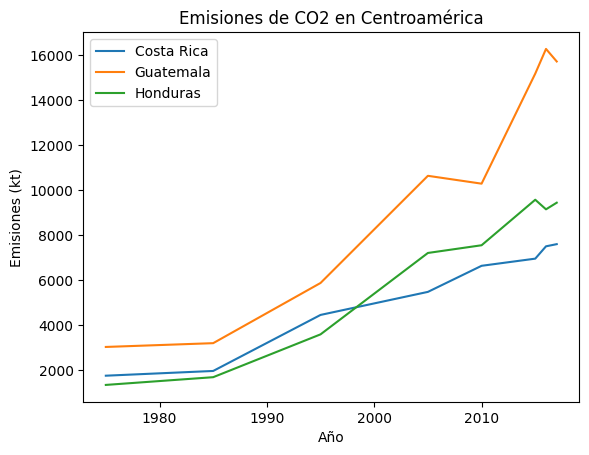

In [21]:
# 5.1 Construye aquí el gráfico de líneas
import matplotlib.pyplot as plt

for pais in paises:
    datos = df_totales[df_totales["pais"] == pais]
    plt.plot(datos["anio"], datos["valor"], label=pais)

plt.title("Emisiones de CO2 en Centroamérica")
plt.xlabel("Año")
plt.ylabel("Emisiones (kt)")
plt.legend()
plt.show()

### Lectura del gráfico 1
Lo elegí porque permite ver claramente la evolución de las emisiones a lo largo del tiempo y muestra cómo han crecido o cambiado en cada país.

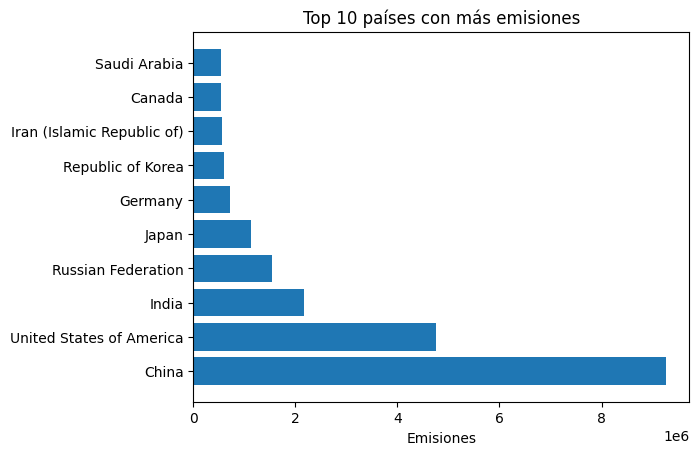

In [22]:
# 5.2 Construye aquí el gráfico de barras comparativo
ultimo_anio = df_totales["anio"].max()

df_ultimo = df_totales[df_totales["anio"] == ultimo_anio]

top10 = df_ultimo.sort_values(by="valor", ascending=False).head(10)

plt.barh(top10["pais"], top10["valor"])
plt.title("Top 10 países con más emisiones")
plt.xlabel("Emisiones")
plt.show()

### Lectura del gráfico 2
Lo elegí porque facilita comparar valores entre países en un año específico y permite identificar rápidamente cuáles tienen mayores o menores emisiones.

### Interpretación de gráficos del Bloque 5
Los gráficos muestran que las emisiones totales han aumentado considerablemente con el tiempo, especialmente en países como China y Estados Unidos. Sin embargo, al observar las emisiones per cápita, se nota que estos países no siempre son los más altos, lo que evidencia diferencias en el consumo individual. Además, se ve que algunos países mantienen valores más estables, mientras otros presentan crecimientos más acelerados. En conjunto, esto refleja que el impacto ambiental varía según el tamaño del país y sus hábitos de consumo.

---
## Bloque 6 — Informe final crítico (20 pts)

### Objetivo
Cerrar el examen con una síntesis crítica basada en evidencia, no solo con una lista de resultados.

### Debes redactar un informe de 6 a 8 líneas que incluya obligatoriamente
- **2 hallazgos numéricos concretos**
- **1 limitación real del análisis**
- **1 comparación explícita entre emisiones totales y per cápita**
- **1 conclusión final** sobre el comportamiento de las emisiones en los países analizados
- **1 recomendación o advertencia final** basada en tus datos
- **coherencia clara** entre lo que exploraste, calculaste, graficaste y concluiste

### Regla importante
No describas solo resultados: explica qué significan.

### Nivel esperado
- **No logrado:** texto genérico sin cifras ni juicio analítico.
- **Inicial:** incluye alguna cifra, pero la conclusión es débil o desconectada.
- **Intermedio:** presenta hallazgos, limitación y conclusión coherente.
- **Logrado:** sintetiza, compara, limita e interpreta con evidencia concreta y criterio, y además propone una recomendación o advertencia defendible.


### Informe final crítico
El análisis muestra una fuerte desigualdad en las emisiones, donde el valor máximo supera los 9,257,934 mientras la mediana es de apenas 50.21, lo que significa que pocos países concentran la mayor parte del impacto global. Además, entre 1975 y 2017 se observa un aumento sostenido en países grandes como China, lo que refleja procesos de industrialización y crecimiento económico. Al comparar métricas, se entiende que altas emisiones totales no siempre implican alto consumo individual, por lo que el impacto real cambia según la perspectiva. Una limitación es la ausencia de variables como población o economía, lo que impide explicar completamente las causas. En conjunto, las emisiones han crecido de forma desigual y concentrada. Como conclusión, el problema es global pero impulsado por pocos países. Se recomienda evaluar ambas métricas para tomar decisiones más justas y precisas.

---
## Criterios de corrección visibles para el estudiante
- Se descontarán puntos si usas nombres distintos a los exigidos y eso dificulta la revisión.
- Se descontarán puntos si respondes con texto sin evidencia numérica.
- Se descontarán puntos si usas `pandas` para resolver lo que se pidió explícitamente con Python base.
- Se descontarán puntos si confundes emisiones totales con emisiones per cápita.
- Se descontarán puntos si generas gráficos sin título o sin ejes rotulados.
- Se reconocerá crédito parcial cuando el razonamiento sea correcto aunque el resultado final no sea exacto.
- Se valorará especialmente la coherencia entre exploración, análisis, gráficos e informe final.


## Checklist final de entrega
- [ ] Cargué y exploré el archivo correctamente.
- [ ] Expliqué qué representa una fila del dataset.
- [ ] Expliqué la diferencia entre emisiones totales y per cápita.
- [ ] Creé `df_trabajo`.
- [ ] Creé `df_totales_es` y `df_per_capita_es`.
- [ ] Creé `renombrar_columnas_es(df)` y `separar_por_tipo(df, tipo_emision)`.
- [ ] Escribí una `prediccion_inicial`.
- [ ] Creé `registros_totales`.
- [ ] Creé `resumen_pais(registros, pais)`.
- [ ] Construí `reporte_centroamerica_base`.
- [ ] Comparé mi predicción con la evidencia.
- [ ] Construí `reporte_total_centroamerica`.
- [ ] Construí `reporte_promedio_centroamerica`.
- [ ] Construí `conversiones_costa_rica`.
- [ ] Creé `comparar_paises(df, paises)`.
- [ ] Construí `comparacion_2017` y la usé como evidencia visible.
- [ ] Contrasté emisiones totales vs per cápita con un ejemplo concreto.
- [ ] Generé los 2 gráficos.
- [ ] Expliqué por qué cada gráfico era útil.
- [ ] Escribí el informe final crítico con recomendación o advertencia.
